<h1>NEB Calculations for LDA</h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ase.units as units

## Tratando os dados

In [5]:
print("1 kcal em eV:", units.kcal)
print("Valor do número de Avogrado:", units.mol)

1 kcal em eV: 2.611447418269555e+22
Valor do número de Avogrado: 6.022140857e+23


In [ ]:
# Data from /home/jvc/ZnO_database/DFT_LDA/NEB_Calculation/neb.out

E_fu = np.array([
-12270.0948266,
-12270.0359710,
-12269.9091661,
-12269.7679158,
-12269.6462530,
-12269.5654266,
-12269.5372276,
]) / 2 # eV

print("Energia por formula-unit (/2):\n", E_fu)

Energia por formula-unit (/2):
 [-6135.0474133  -6135.0179855  -6134.95458305 -6134.8839579
 -6134.8231265  -6134.7827133  -6134.7686138 ]


In [ ]:
# A menor energia 
np.argmin(E)

0

In [8]:

deltaE_fu = E_fu - E_fu.min()

In [9]:
deltaE_meV_fu = deltaE_fu * 1_000

In [10]:
print("DeltaE em meV por formula-unit:", deltaE_meV_fu)

DeltaE em meV por formula-unit: [  0.       29.4278   92.83025 163.4554  224.2868  264.7     278.7995 ]


In [13]:
fator = 1e-3 / (units.kcal / units.mol) # converte de meV/fu para kcal/mol

barreira_meV_fu = deltaE_meV_fu.max()
barreira_kcal_mol = barreira_meV_fu * fator

print("Barreira em kcal/mol:", barreira_kcal_mol)
print("Barreira em meV/fu", barreira_meV_fu)

Barreira em kcal/mol: 6.42926925548814
Barreira em meV/fu 278.7994999998773


In [16]:
barreira_meV_fu / 1000

0.2787994999998773

## Plotando

In [14]:
plt.style.use("/home/jvc/ZnO_database/mpl_themes/jvc.mplstyle")

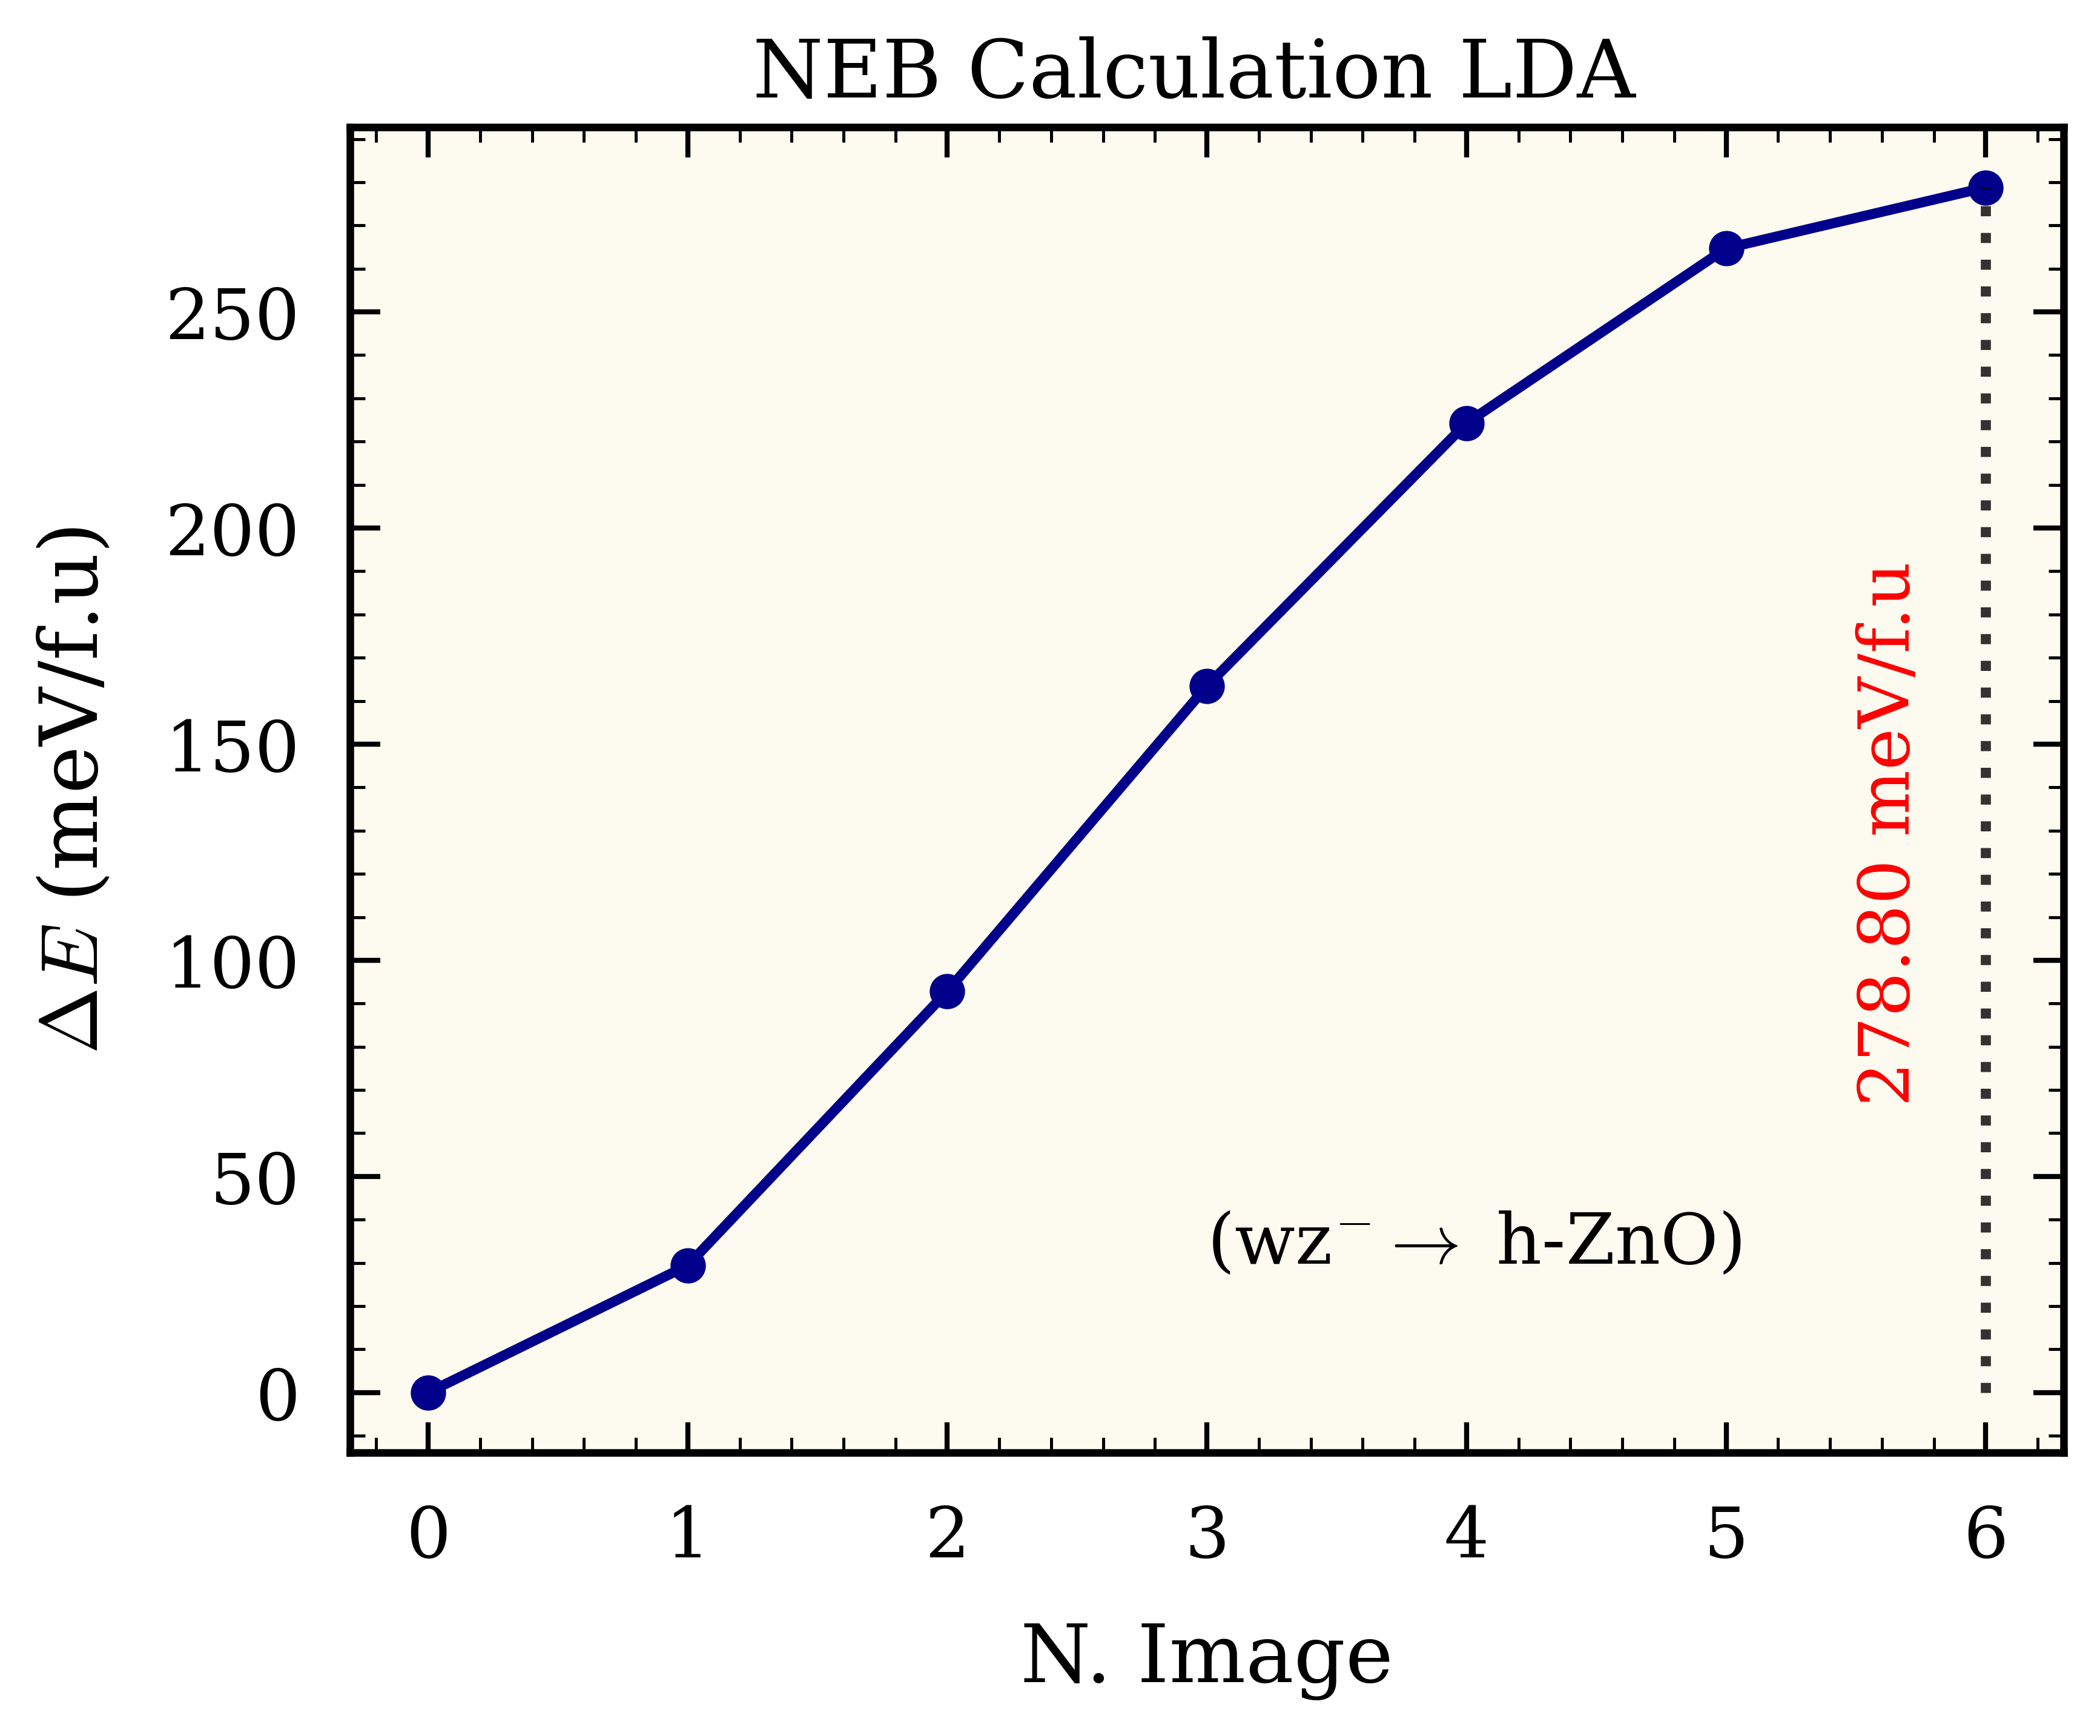

In [56]:
fig, ax = plt.subplots(dpi=600)

ax.plot(deltaE_meV_fu, marker="o", color="darkblue")
ax.set_title(r"NEB Calculation LDA ")
ax.set_xlabel("N. Image")
ax.set_ylabel(r"$\Delta E$ (meV/f.u)")
ax.text(x=3, y=30, s=r"(wz$^{-} \rightarrow$ h-ZnO)")
ax.vlines(
    x=np.argmax(deltaE_meV_fu),
    ymin=0,
    ymax=deltaE_meV_fu.max(),
    color="black",
    linestyle=":",
    alpha=0.8,
)
ax.text(
    x=5.5,
    y=deltaE_meV_fu.max()*0.25,
    s=f"{barreira_meV_fu:.2f} meV/f.u",
    rotation=90,
    color="red",
)
plt.show()

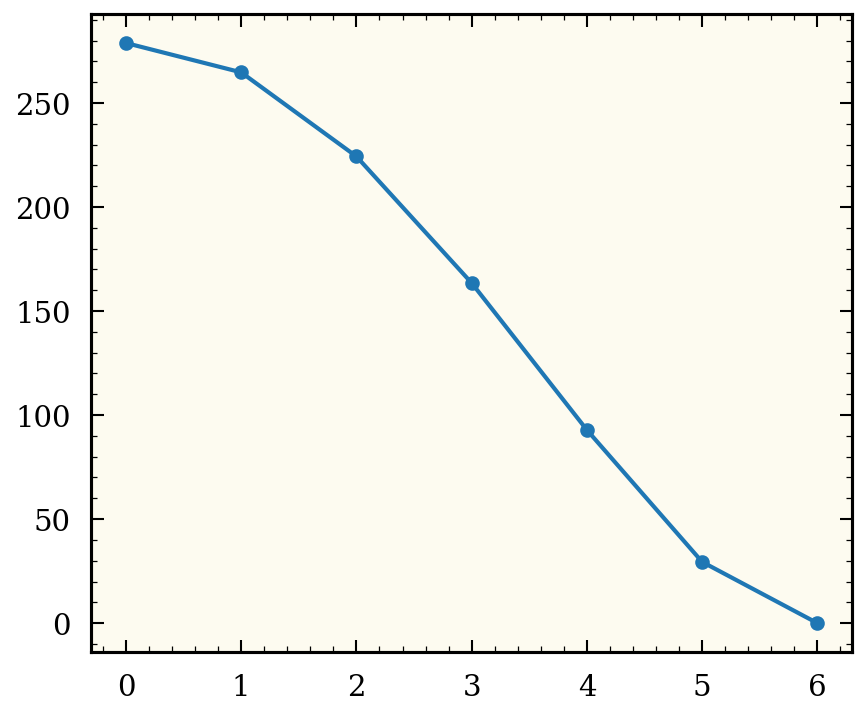

In [47]:
plt.plot(deltaE_meV_fu[-1::-1], marker='o')

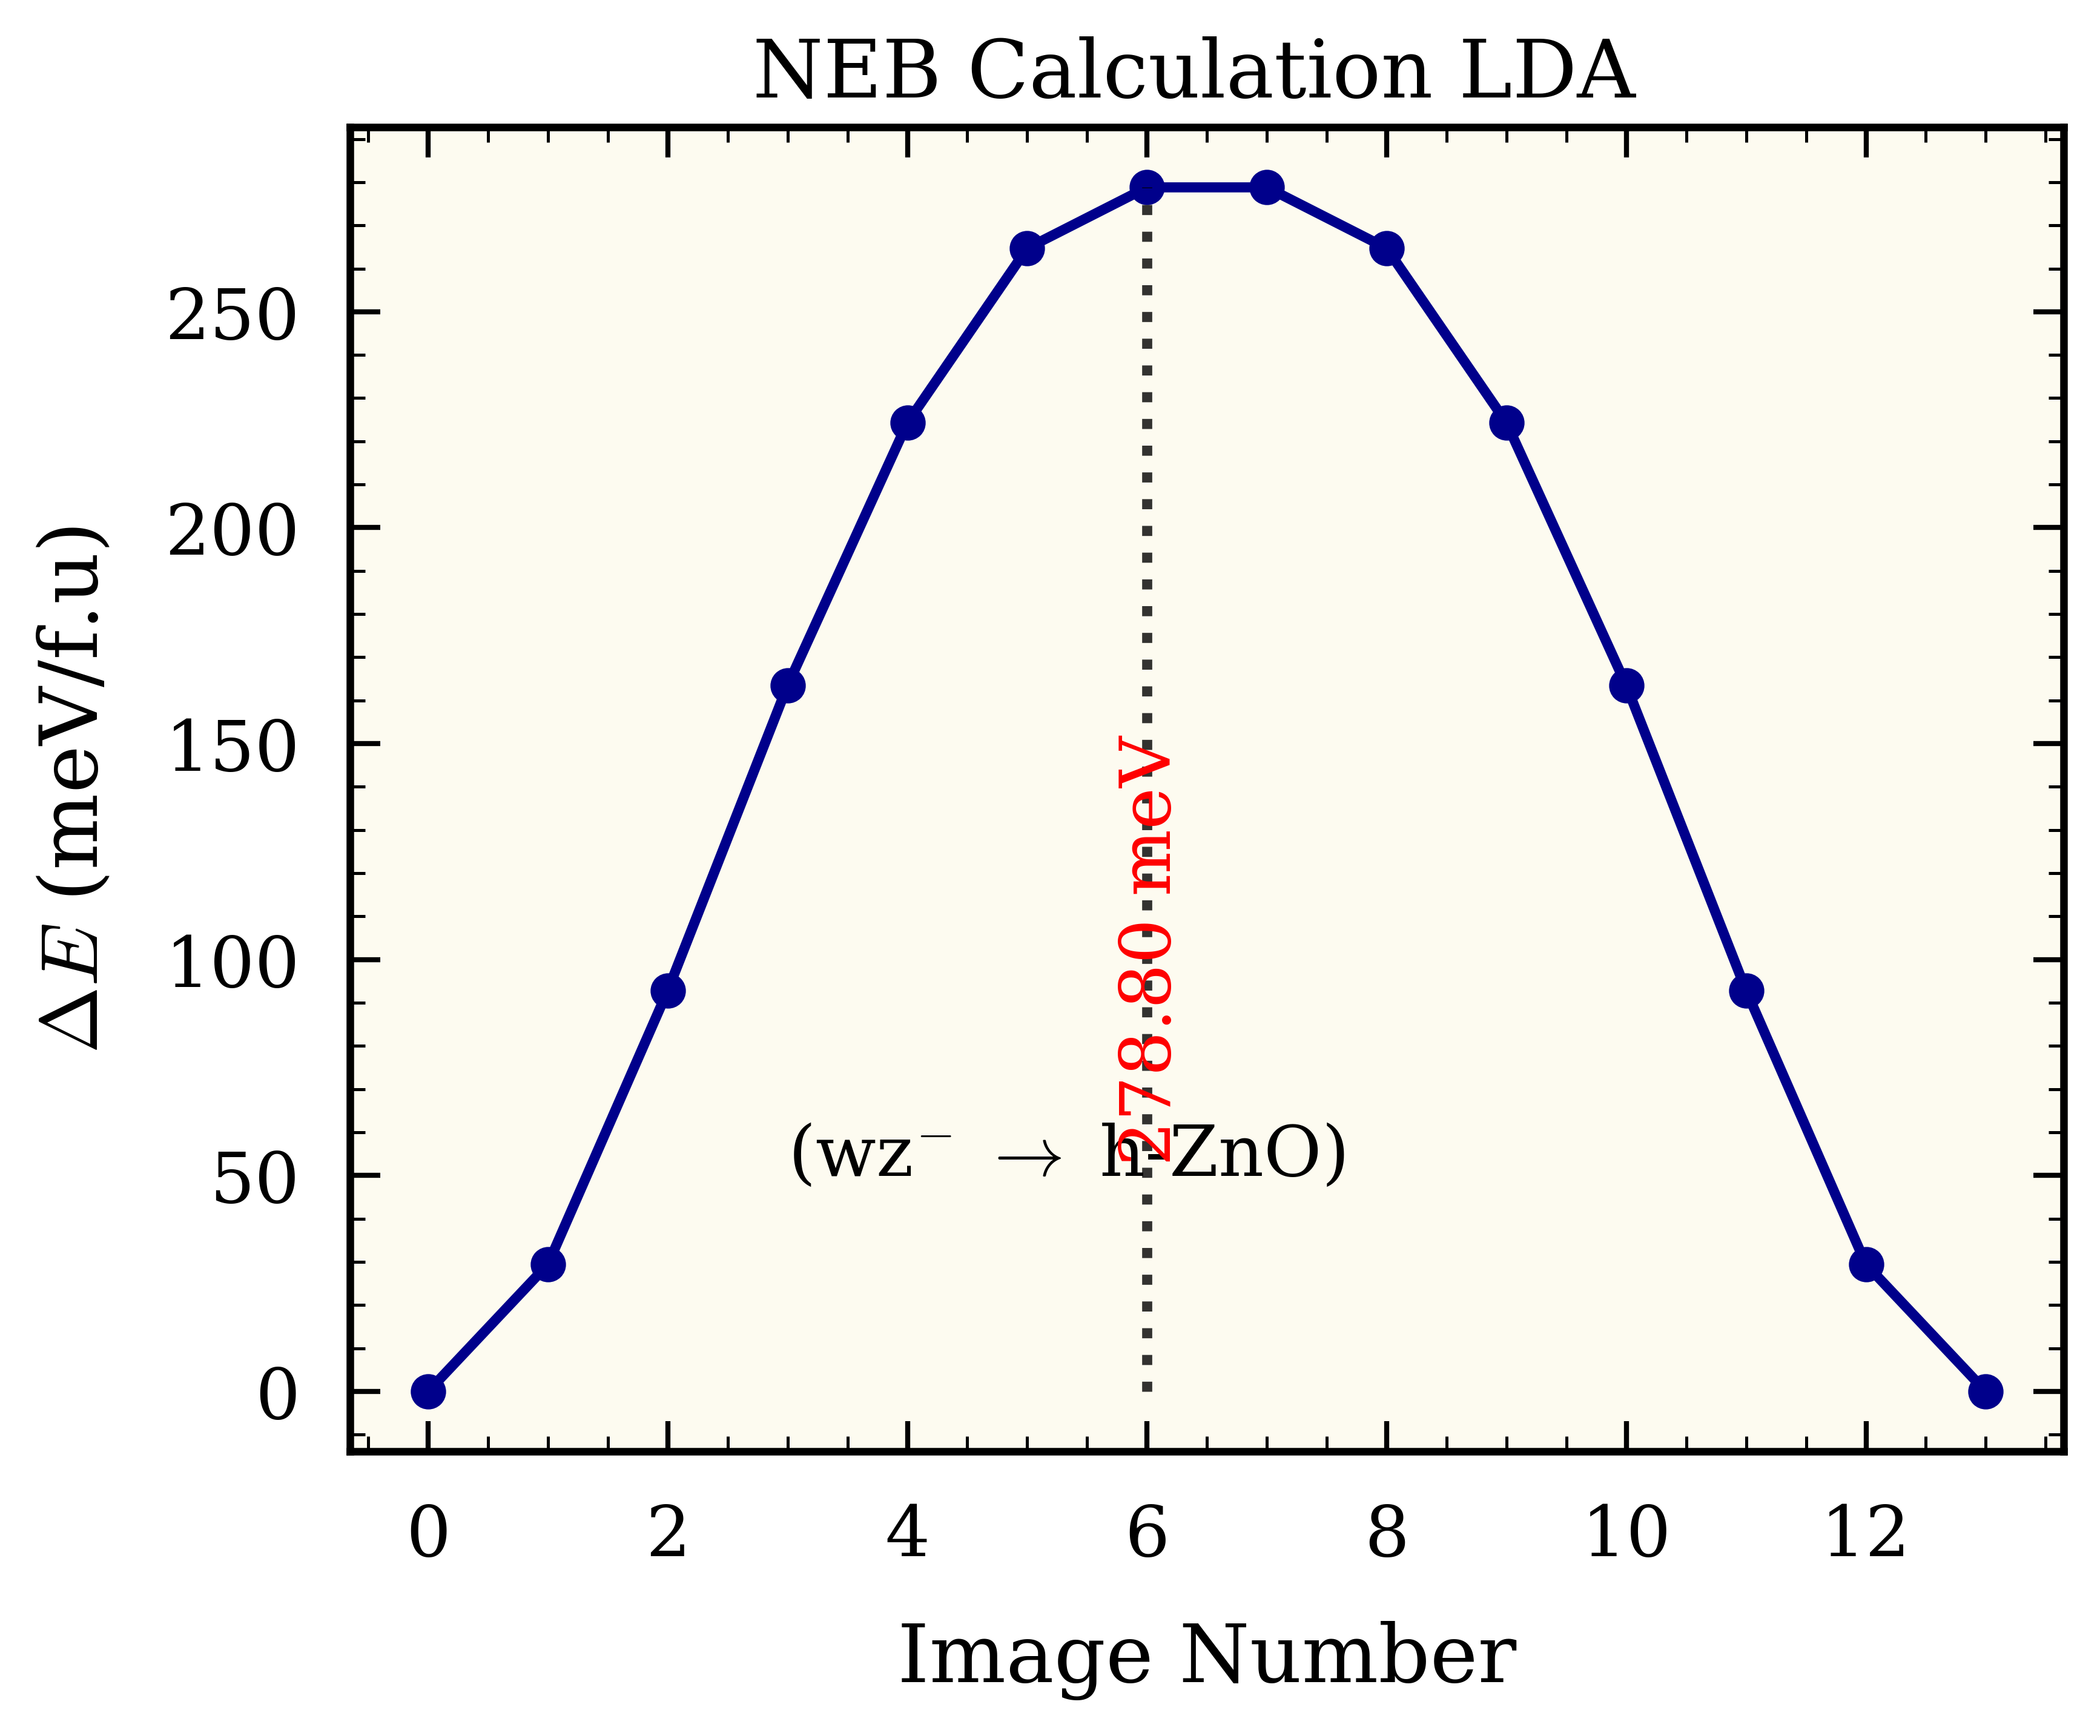

In [49]:
fig, ax = plt.subplots(dpi=600)
symmetric_form = np.concatenate([deltaE_meV_fu, deltaE_meV_fu[::-1]])
ax.plot(symmetric_form, marker="o", color="darkblue")
ax.set_title(r"NEB Calculation LDA ")
ax.set_xlabel("Image Number")
ax.set_ylabel(r"$\Delta E$ (meV/f.u)")
ax.text(x=3, y=50, s=r"(wz$^{-}$ $\rightarrow$ h-ZnO)")
ax.vlines(
    x=np.argmax(deltaE_meV_fu),
    ymin=0,
    ymax=deltaE_meV_fu.max(),
    color="black",
    linestyle=":",
    alpha=0.8,
)
ax.text(
    x=5.75,
    y=deltaE_meV_fu.max()*0.2,
    s=f"{barreira_meV_fu:.2f} meV",
    rotation=90,
    color="red",
)
plt.show()

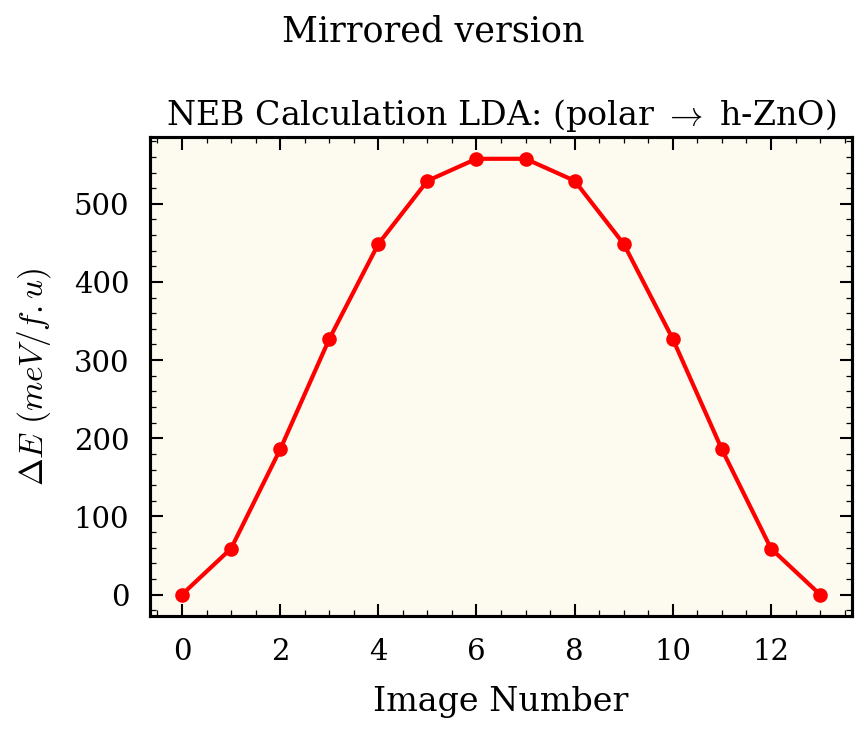

In [ ]:
fig, ax = plt.subplots()
fig.suptitle("Mirrored version",x=0.5)

ax.plot(np.concatenate([deltaE, deltaE[::-1]]) * 1_000, marker="o", color="red")
ax.set_title(r"NEB Calculation LDA: (polar $\rightarrow$ h-ZnO)")
ax.set_xlabel("Image Number")
ax.set_ylabel(r"$\Delta E \ (meV/f.u)$")

plt.show()